In [2]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

# Please replace the brackets below with the drive location of your folders which included subfolders for images
# Sample path: /content/drive/My Drive/ImageClassification
TRAINING_PATH = '/content/drive/MyDrive/Training Classes Camps/AI Club/scoliosis project/Train'
VALIDATION_PATH = '/content/drive/MyDrive/Training Classes Camps/AI Club/scoliosis project/Validate'

In [4]:
def create_model(base_model, num_classes):
    import tensorflow as tf
    # Grab the last layer and add a few extra layers to it
    x=base_model.output
    x=GlobalAveragePooling2D()(x)
    # Dense layer 1
    x=tf.keras.layers.Dense(100,activation='relu', kernel_initializer=tf.keras.initializers.VarianceScaling(), use_bias=True)(x)

    # Final layer with softmax activation
    preds=tf.keras.layers.Dense(num_classes,activation='softmax', kernel_initializer=tf.keras.initializers.VarianceScaling(), use_bias=False)(x)

    # Create the final model
    model=Model(inputs=base_model.input,outputs=preds)
    return model


In [ ]:
def get_optimizer(optimizer_name, learning_rate):
    # Import keras optimizers
    from tensorflow.keras.optimizers import Adam, Adadelta, Adagrad, Adamax, Ftrl, Nadam, RMSprop, SGD
    print('Selected Optimizer', optimizer_name)
    switcher = {
        'Adadelta': Adadelta(learning_rate=learning_rate),
        'Adagrad': Adagrad(learning_rate=learning_rate),
        'Adam': Adam(learning_rate=learning_rate),
        'Adamax': Adamax(learning_rate=learning_rate),
        'FTRL': Ftrl(learning_rate=learning_rate),
        'NAdam': Nadam(learning_rate=learning_rate),
        'RMSprop': RMSprop(learning_rate=learning_rate),
        'Gradient Descent': SGD(learning_rate=learning_rate)
    }
    # If optimizer_name is empty, Adam will be return as default optimizer
    return switcher.get(optimizer_name, Adam(learning_rate=learning_rate))


In [ ]:

# Import packages needed to create a image classification model
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

from keras.applications.resnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense,GlobalAveragePooling2D
from keras.models import Model
from tensorflow.keras import regularizers

from tensorflow.keras.preprocessing import image_dataset_from_directory
from keras.callbacks import EarlyStopping
from tensorflow import keras

# Initialize hyper params
epochs = 10 #<-- increase for higher accuracy
base_learning_rate = 0.0001 #decrease for different results; use excel sheet to note down results from each change to learning rate and epochs
optimizer = 'Adam'
BATCH_SIZE = 32

IMG_SIZE = (224, 224)

# Create the data generation pipeline for training and validation
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(TRAINING_PATH,
                                                target_size=IMG_SIZE,
                                                color_mode='rgb',
                                                batch_size=BATCH_SIZE,
                                                class_mode='categorical',
                                                shuffle=True,
                                                )
validation_generator = validation_datagen.flow_from_directory(VALIDATION_PATH,
                                                target_size=IMG_SIZE,
                                                color_mode='rgb',
                                                batch_size=BATCH_SIZE,
                                                class_mode='categorical',
                                                shuffle=True,
                                                )

print(validation_generator.class_indices.keys())
# Download the model, valid alpha values [0.25,0.35,0.5,0.75,1]
base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet', alpha=0.35)
for layer in base_model.layers:
    layer.trainable=False

# Specify the number of classes
num_classes = 2

# Create the base model
model = create_model(base_model,num_classes)

print(len(base_model.layers))

model.compile(optimizer = get_optimizer(optimizer_name=optimizer,learning_rate=base_learning_rate),loss='CategoricalCrossentropy',metrics=['accuracy'])
# Adam optimizer
# loss function will be categorical cross entropy
# evaluation metric will be accuracy

early_stopping_monitor = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=30,
    verbose=0,
    mode='auto',
    baseline=None,
    restore_best_weights=True
)

step_size_train = train_generator.n//train_generator.batch_size
history_fine = model.fit(train_generator,
                        epochs=epochs,
                        validation_data = validation_generator,
                        verbose=1)

model.save("/content/drive/MyDrive/project sample/Models/best_model_mobilenetv2.h5")

Found 162 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
dict_keys(['Cats', 'Dogs'])
154
Selected Optimizer Adam
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4309 - loss: 0.7779 - val_accuracy: 0.6000 - val_loss: 0.6356
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 372ms/step - accuracy: 0.5386 - loss: 0.6808 - val_accuracy: 0.6000 - val_loss: 0.6219
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 297ms/step - accuracy: 0.5779 - loss: 0.6697 - val_accuracy: 0.6500 - val_loss: 0.6005
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 307ms/step - accuracy: 0.6100 - loss: 0.6499 - val_accuracy: 0.7500 - val_loss: 0.5884
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step - accuracy: 0.6996 - loss: 0.5958 - val_accuracy: 0.6500 - val_loss: 0.5711
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 431ms/step - accuracy: 0.7193 - loss: 0.5852 - val_accuracy: 0.7500 - val_loss: 0.5578
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 652ms/step - accuracy: 0.7189 - loss: 0.5813 - val_accuracy: 0.7500 - 

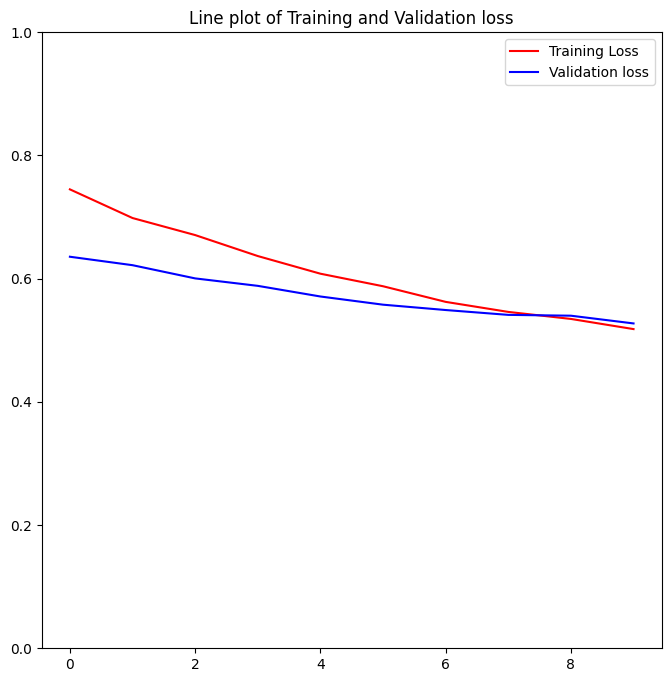

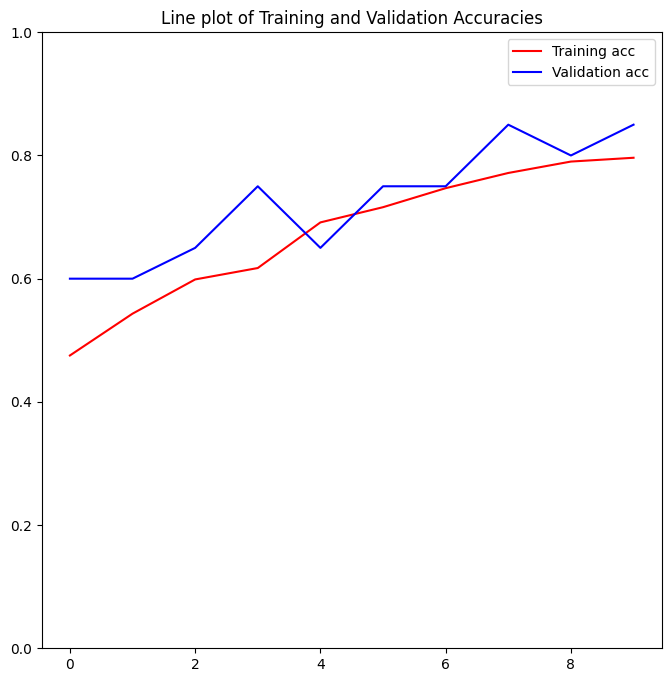

In [ ]:
def visualization():
    import pandas as pd
    df = pd.DataFrame(history_fine.history)
    #loss plots
    plt.figure(figsize=(8,8))
    plt.plot(df['loss'], color='red', label = "Training_loss")
    plt.plot(df['val_loss'], color='blue')
    plt.legend(['Training Loss','Validation loss'],loc = 'best' )
    plt.title('Line plot of Training and Validation loss')
    plt.ylim(0,1)
    plt.show()

    #accuracy plots
    plt.figure(figsize=(8,8))
    plt.plot(df['accuracy'], color='red')
    plt.plot(df['val_accuracy'], color='blue')
    plt.legend(['Training acc','Validation acc'],loc = 'best' )
    plt.title('Line plot of Training and Validation Accuracies')
    plt.ylim(0,1)
    plt.show()

visualization()

In [ ]:

# Import numpy for calculating best model accuracy
import numpy as np
# Populating matrics -> accuracy & loss
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']

loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

print('Training Accuracy: ', acc)
print('Validation Accuracy: ', val_acc)
print('Training Loss: ', loss)
print('Validation Loss: ', val_loss)
best_model_accuracy = history_fine.history['val_accuracy'][np.argmin(history_fine.history['val_loss'])]
print('best model accuracy: ', best_model_accuracy)


Training Accuracy:  [0.4753086566925049, 0.5432098507881165, 0.5987654328346252, 0.6172839403152466, 0.6913580298423767, 0.7160493731498718, 0.7469135522842407, 0.7716049551963806, 0.790123462677002, 0.7962962985038757]
Validation Accuracy:  [0.6000000238418579, 0.6000000238418579, 0.6499999761581421, 0.75, 0.6499999761581421, 0.75, 0.75, 0.8500000238418579, 0.800000011920929, 0.8500000238418579]
Training Loss:  [0.744996964931488, 0.698453426361084, 0.6707949638366699, 0.6367360353469849, 0.6080812215805054, 0.5877118110656738, 0.5623546838760376, 0.5460485219955444, 0.5346473455429077, 0.5181470513343811]
Validation Loss:  [0.6356170773506165, 0.6218992471694946, 0.6004502177238464, 0.5883577466011047, 0.5710741877555847, 0.5577877163887024, 0.5491029024124146, 0.5412356853485107, 0.5399052500724792, 0.5273392200469971]
best model accuracy:  0.8500000238418579


In [ ]:
def seperate_labels(generator):
    x_validation = []
    y_validation = []
    num_seen = 0

    for x, labels in generator:
        x_validation.append(x)
        y_validation.append([argmax(label) for label in labels])
        num_seen += len(x)
        if num_seen == generator.n: break

    x_validation = np.concatenate(x_validation)
    y_validation = np.concatenate(y_validation)
    return x_validation, y_validation


In [ ]:

# Calculate and display the confusion matrix
import matplotlib.pyplot as plt
from numpy.core.fromnumeric import argmax
from sklearn.metrics import ConfusionMatrixDisplay

x_validation, y_validation = seperate_labels(validation_generator)
y_pred = model.predict(x_validation, batch_size=BATCH_SIZE)
predictions = np.apply_along_axis(argmax, 1, y_pred)
display_labels = validation_generator.class_indices.keys()

# ConfusionMatrixDisplay.from_predictions(y_validation, predictions, display_labels=display_labels, cmap="binary")
# plt.show()


/tmp/ipython-input-1308144587.py:3: DeprecationWarning: numpy.core.fromnumeric is deprecated and has been renamed to numpy._core.fromnumeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.fromnumeric.argmax.
  from numpy.core.fromnumeric import argmax


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


Confusion Matrix

In [ ]:
'''import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
plt.figure(figsize = (10,10))
sns.heatmap(confusion_matrix(y_validation, predictions), annot = True, fmt = 'g', cmap = "Blues",xticklabels=display_labels, yticklabels=display_labels)
plt.title("Confusion Matrix")
plt.show()'''

Confusion Matrix in percentage

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels):
    # Compute normalized confusion matrix
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    # Convert to percentages
    cm_percentage = cm * 100

    # Create annotations for confusion matrix values with the percentage sign
    annotations = np.array([[f'{val:.2f}%' for val in row] for row in cm_percentage])

    # Plot the confusion matrix
    plt.figure(figsize=(10, 10))
    sns.heatmap(cm_percentage, annot=annotations, fmt='', cmap="Blues",
                xticklabels=labels, yticklabels=labels)

    plt.title("Normalized Confusion Matrix")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

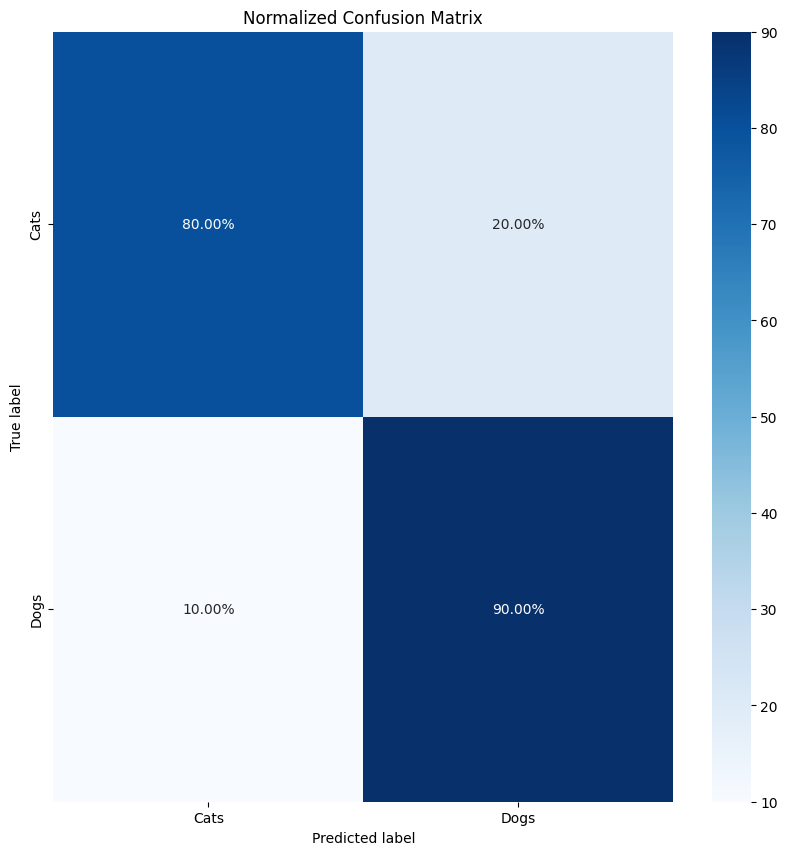

In [ ]:
plot_confusion_matrix(y_validation, predictions, display_labels)

Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_validation, predictions))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.82      0.90      0.86        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20



In [ ]:

# Predicting code for an image
from tensorflow.keras.preprocessing import image
# Please replace the brackets below with the location of your image which need to predict
img_path = '/content/drive/MyDrive/project sample/Test/Dogs/dog_1.jpeg'
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)
prediction = model.predict(img_preprocessed)
print(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
[[0.48273647 0.5172635 ]]
